In [1]:
#######################################
# IMPORT LIBRARIES 
#######################################

import yfinance as yf
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
#####################################################
# DOWNLOAD MARKET DATA 
######################################################

# Brent crude
brent = yf.download('BZ=F', start='2024-01-01')
# WTI crude
wti = yf.download('CL=F', start='2024-01-01')
# US Dollar Index (DXY)
dxy = yf.download('DX-Y.NYB', start='2024-01-01')
# Gold
gold = yf.download('GC=F', start='2024-01-01')
# Natural gas
natgas = yf.download('NG=F', start='2024-01-01')
# S&P 500
sp500 = yf.download('^GSPC', start='2024-01-01')
#copper 
copper = yf.download('HG=F', start='2024-01-01')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
#####################################################
# EXTRACT CLOSING PRICES
######################################################

brent_close = brent['Close']['BZ=F']
wti_close = wti['Close']['CL=F']
dxy_close = dxy['Close']['DX-Y.NYB']
gold_close = gold['Close']['GC=F']
natgas_close = natgas['Close']['NG=F']
sp500_close = sp500['Close']['^GSPC']
copper_close = copper['Close']['HG=F']

In [4]:
#######################################################
# CREATE MARKET DATAFRAME
#######################################################

market_data = pd.DataFrame({
    'Brent': brent_close,
    'DXY': dxy_close,
    'Gold': gold_close,
    'Natural Gas': natgas_close,
    'S&P 500': sp500_close,
    'Copper': copper_close
})
market_data.head()

,Brent,DXY,Gold,Natural Gas,S&P 500,Copper
Date,,,,,,
2024-01-02,75.889999,102.199997,2064.399902,2.568,4742.830078,3.8690
2024-01-03,78.250000,102.459999,2034.199951,2.668,4704.810059,3.8475
2024-01-04,77.589996,102.419998,2042.300049,2.821,4688.680176,3.8310
2024-01-05,78.760002,102.410004,2042.400024,2.893,4697.240234,3.7945
2024-01-08,76.120003,102.209999,2026.599976,2.980,4763.540039,3.7995


In [5]:
#####################################################
# CREATE CORRELATION MATRIX
#####################################################

correlation_matrix = market_data.corr()

correlation_matrix


,Brent,DXY,Gold,Natural Gas,S&P 500,Copper
Brent,1.000000,0.189514,0.009632,-0.464044,-0.007504,0.185469
DXY,0.189514,1.000000,-0.731381,-0.233333,-0.622634,-0.630736
Gold,0.009632,-0.731381,1.000000,0.491417,0.906859,0.883724
Natural Gas,-0.464044,-0.233333,0.491417,1.000000,0.495887,0.393558
S&P 500,-0.007504,-0.622634,0.906859,0.495887,1.000000,0.819687
Copper,0.185469,-0.630736,0.883724,0.393558,0.819687,1.000000


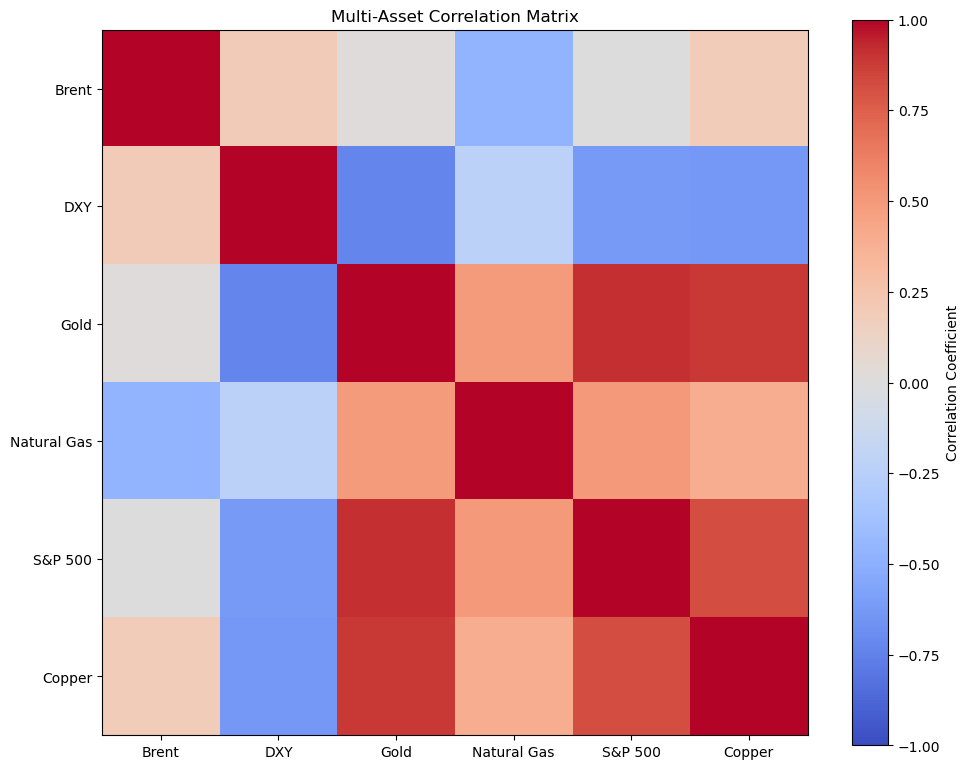

In [7]:
#####################################################
# CREATE HEATMAP
#####################################################

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
# Color Scale
plt.colorbar(label='Correlation Coefficient')
# Axis Labels
plt.xticks(range(len(correlation_matrix.columns)),correlation_matrix.columns)
plt.yticks(range(len(correlation_matrix.columns)),correlation_matrix.columns)
# Title
plt.title('Multi-Asset Correlation Matrix')
plt.tight_layout()
plt.savefig('Correlation_Matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Multi-Asset Correlation Matrix Analysis 2024 - 2026
###### Commodity linked assets showed strong positive relationships
- Correlation analysis demonstrated strong positive relationships between commodity-linked and growth-sensitive assets, particularly among Brent crude, copper, and equity markets
###### Brent crude & copper exhibited positive correlation
- The positive correlation between Brent crude and copper suggests that both commodities remained sensitive to broader global growth expectations and industrial demand conditions.
###### S&P 500 and gold moved positively together during the observed period 
- Despite gold traditionally being viewed as a defensive asset, the observed positive relationship with equities suggests that both markets may have benefited simultaneously from liquidity-driven macro conditions.
###### DXY maintained inverse relationship with several commodities 
- The US Dollar Index demonstrated broadly negative correlations against commodity assets, reflecting the traditional inverse relationship between dollar strength and dollar-denominated commodity pricing
###### Natural gas displayed weaker and less stable correlations
- Natural gas correlations remained comparatively weaker and less consistent, suggesting greater sensitivity to commodity-specific supply, storage, and seasonal factors.
###### Commodity structures imply shifting macro regimes
- The variation in correlation intensity across asset classes may indicate changing macroeconomic and geopolitical regimes throughout the sample period.
###### Correlation does not apply causation
- While correlation analysis identifies statistical relationships between markets, it does not necessarily imply direct causation between asset price movements.
###### Conclusive thoughts
- Overall, the correlation matrix highlights the interconnected nature of global macro and commodity markets, while also demonstrating that certain assets remain influenced by highly specific market fundamentals.